## This project is a placement prediction project.

**For a student, `placement` generally means getting a temporary job or hands-on work experience tied to their studies, or securing a permanent job through their school before graduating**

In [72]:
from sklearn.linear_model import LogisticRegression # This is a classification problem so we'll be using logistic regression for it
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

### Data Cleaning/Preprocessing

In [73]:
# Loading the dataset

df = pd.read_csv('student_dataset_10000_rows.csv')

In [74]:
# Checking for duplicates

df.duplicated().sum()

np.int64(0)

In [75]:
# Checking for null values

df.isnull().sum()

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

In [76]:
# Checking the total number of columns

df.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='str')

In [77]:
# Checking the info of the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  str    
dtypes: float64(1), int64(6), str(1)
memory usage: 625.1 KB


In [78]:
# How correlated the data is tells us which feature affects the other the most.
# 1 = Strongly related
# 0 = Moderately related
# -1 = Not related

df.corr(numeric_only=True)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
study_hours,1.000000,0.003801,-0.005255,0.006684,-0.000425,0.009451,0.562528
attendance,0.003801,1.000000,-0.003981,-0.014539,-0.012892,0.001588,0.223367
sleep_hours,-0.005255,-0.003981,1.000000,-0.000038,-0.008234,0.023916,0.144675
internet_usage,0.006684,-0.014539,-0.000038,1.000000,0.020536,0.005371,-0.151896
assignments_completed,-0.000425,-0.012892,-0.008234,0.020536,1.000000,0.004178,0.387609
previous_score,0.009451,0.001588,0.023916,0.005371,0.004178,1.000000,0.318805
exam_score,0.562528,0.223367,0.144675,-0.151896,0.387609,0.318805,1.000000


In [79]:
df.head(2)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.0,Placed
1,4,69,5,3,8,56,100.0,Placed


In [80]:
# Checking the number of values present in the target column
df['placement_status'].value_counts()

placement_status
Placed        8356
Not Placed    1644
Name: count, dtype: int64

In [81]:
# Mapping the target class

df['placement_status'] = df['placement_status'].map({'Placed': 1, 'Not Placed': 0})

In [82]:
df['placement_status'].value_counts()

placement_status
1    8356
0    1644
Name: count, dtype: int64

In [83]:
comparison = df[['study_hours', 'sleep_hours']]

# Exploratory Data Analysis
---

### Univariate Analysis

<Axes: ylabel='Count'>

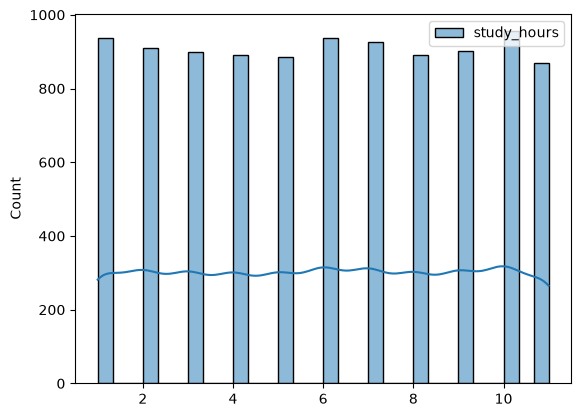

In [84]:
sns.histplot(df[['study_hours']], bins=30, kde=True)

<Axes: ylabel='Count'>

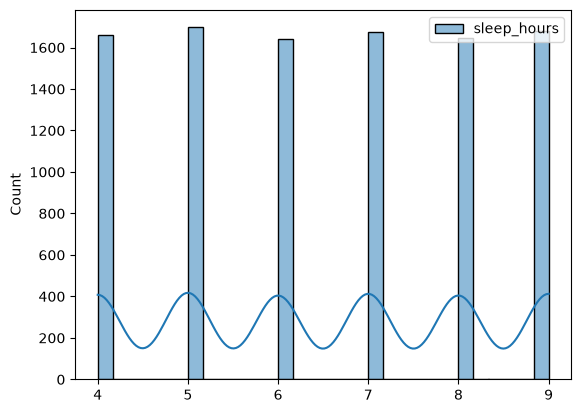

In [85]:
sns.histplot(df[['sleep_hours']], bins=30, kde=True)

<Axes: ylabel='Count'>

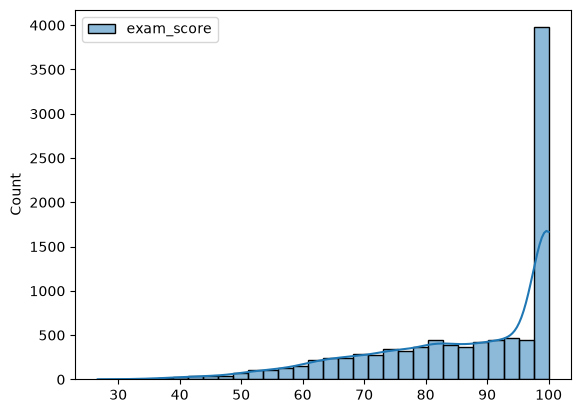

In [86]:
sns.histplot(df[['exam_score']], bins=30, kde=True)

# This is heavily skewed on the left.

### Bivariate Analysis

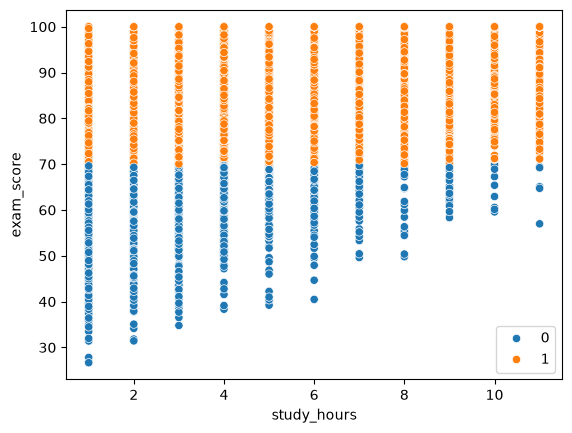

In [99]:
sns.scatterplot(x='study_hours', y='exam_score', data=df, hue='placement_status')

plt.legend()

In [88]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,1
1,4,69,5,3,8,56,100.00,1
2,11,60,7,6,10,45,100.00,1
3,8,99,9,8,4,55,90.17,1
4,5,52,8,6,8,40,78.82,1


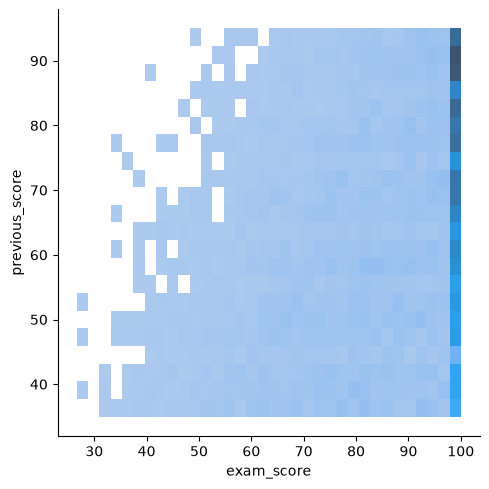

In [100]:
sns.displot(x='exam_score', y='previous_score', data=df)

In [90]:
df.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='str')

In [91]:
# df.nsmallest(3, 'sleep_hours')

df.head(3)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.0,1
1,4,69,5,3,8,56,100.0,1
2,11,60,7,6,10,45,100.0,1


## Spliting the dataset test and train

In [92]:
from sklearn.model_selection import train_test_split

In [106]:
X = df.drop('placement_status', axis=1)
X = X.values
X = np.array(X)
X

array([[  7.  ,  56.  ,   8.  , ...,  10.  ,  62.  , 100.  ],
       [  4.  ,  69.  ,   5.  , ...,   8.  ,  56.  , 100.  ],
       [ 11.  ,  60.  ,   7.  , ...,  10.  ,  45.  , 100.  ],
       ...,
       [ 10.  ,  44.  ,   8.  , ...,  10.  ,  37.  ,  95.94],
       [ 10.  ,  75.  ,   7.  , ...,   8.  ,  52.  ,  88.61],
       [  2.  ,  70.  ,   6.  , ...,  16.  ,  52.  ,  78.96]],
      shape=(10000, 7))

In [107]:
y = df['placement_status']
y = y.values
y = np.array(y)
y

array([1, 1, 1, ..., 1, 1, 1], shape=(10000,))

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    stratify = y,
    random_state = 42,
    shuffle = True
)

In [110]:
print(X_train.shape, X_test.shape)

(7000, 7) (3000, 7)


In [111]:
print(y_train.shape, y_test.shape)

(7000,) (3000,)


In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [113]:
# Scaling the training dataset for better prediction

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Training with Logistic Regression

> - **The goal is to predict the right class from the two classes, `Placed` or `Not-Placed`**

In [114]:
log_reg = LogisticRegression()

model = log_reg.fit(X_train_scaled, y_train)

In [115]:
model.intercept_

array([14.20042957])

In [116]:
prediction = model.predict(X_test_scaled)

In [118]:
print(f'Model Prediction   --->   {prediction[:10]}\n')
print(f'Actual Prediction  --->   {y_test[:10]}')

Model Prediction   --->   [1 1 0 1 1 1 0 1 1 0]

Actual Prediction  --->   [1 1 0 1 1 1 0 1 1 0]


##### Checking the performance of our model using an evaluation metric.

In [119]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

In [120]:
def evaluation_metric(y_true, y_pred):
    precision = precision_score(y_true, y_pred, average='micro')
    recall = recall_score(y_true, y_pred, average='micro')
    f1 = f1_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)

    print(f'Precision Score: {precision:.4f}')
    print(f'Recall Score: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'Accuracy Score: {accuracy:.4f}')

In [121]:
# Evaluation Metric

evaluation_metric(y_test, prediction)

Precision Score: 0.9980
Recall Score: 0.9980
F1 Score: 0.9980
Accuracy Score: 0.9980


In [122]:
y = model.predict(X_test_scaled)
print(classification_report(y_test, y))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       493
           1       1.00      1.00      1.00      2507

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [132]:
type(y)
y = y.reshape(-1, 1)
y

array([[1],
       [1],
       [0],
       ...,
       [1],
       [1],
       [0]], shape=(3000, 1))

In [134]:
plt.scatter(model.predict(y))

ValueError: X has 1 features, but LogisticRegression is expecting 7 features as input.